In [10]:
import pandas as pd 
df =pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [11]:
print("shape of Data",df.shape)

shape of Data (9800, 18)


In [12]:
print("Coumns Names:",df.columns)

Coumns Names: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

## Data Cleaning

In [14]:
print("Missing Values:\n",df.isnull().sum())

Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [15]:
df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].median())
print(df.isnull().sum().sum())

0


In [16]:
print("Duplicates:",df.duplicated().sum())

Duplicates: 0


In [17]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [18]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed", dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed", dayfirst=True)

In [19]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object

In [20]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Year"] = df["Order Date"].dt.year
df["Month_Number"] = df["Order Date"].dt.month
df["Month"] = df["Order Date"].dt.to_period("M")

## EDA-(Exploratory Data Analysis)

#### Monthly sales trend

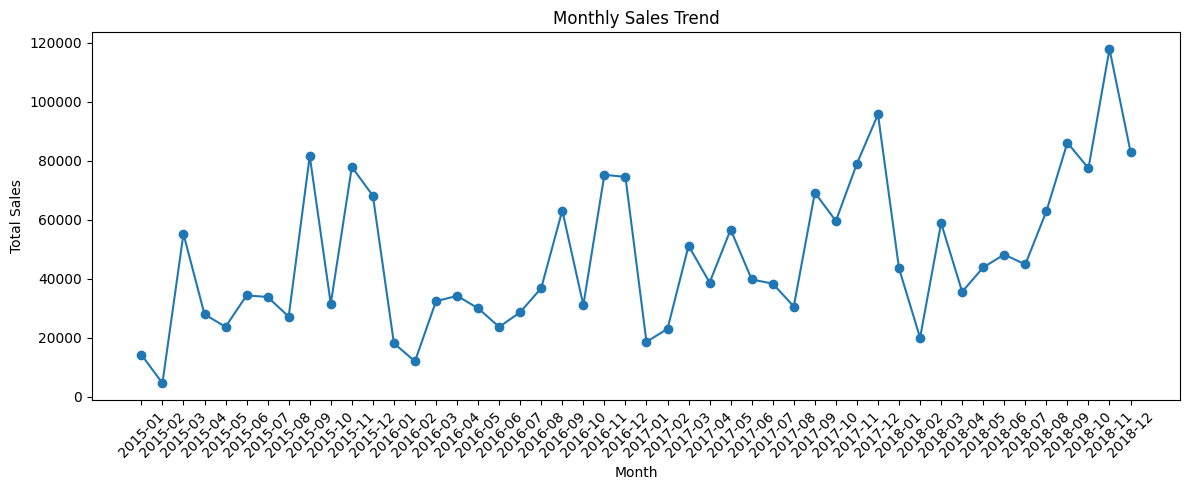

In [21]:
import matplotlib.pyplot as plt
monthly_sales = df.groupby("Month")["Sales"].sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sales by region

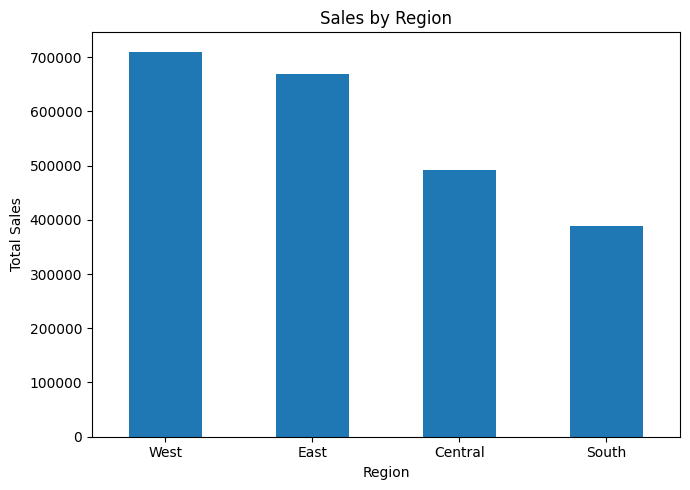

In [22]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Top 10 products by sales

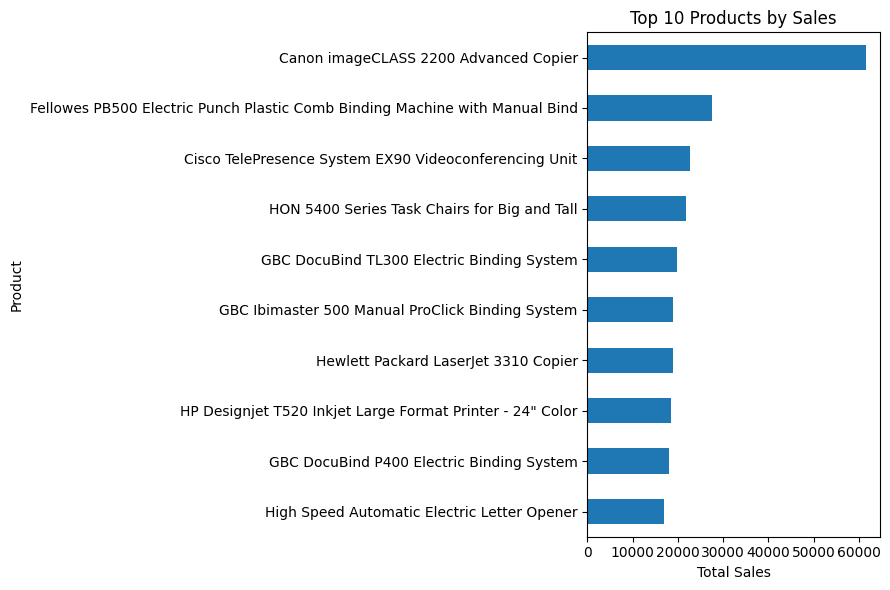

In [23]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)
plt.figure(figsize=(9, 6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Sales by customer segment

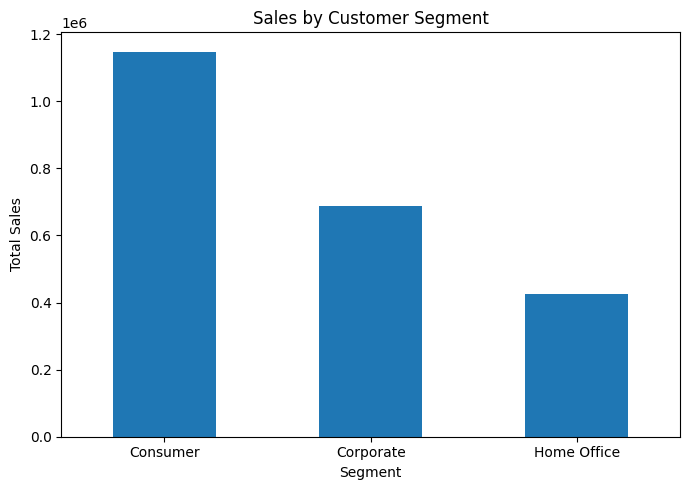

In [24]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
segment_sales.plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
## Correlation heatmap for available numeric analysis variables

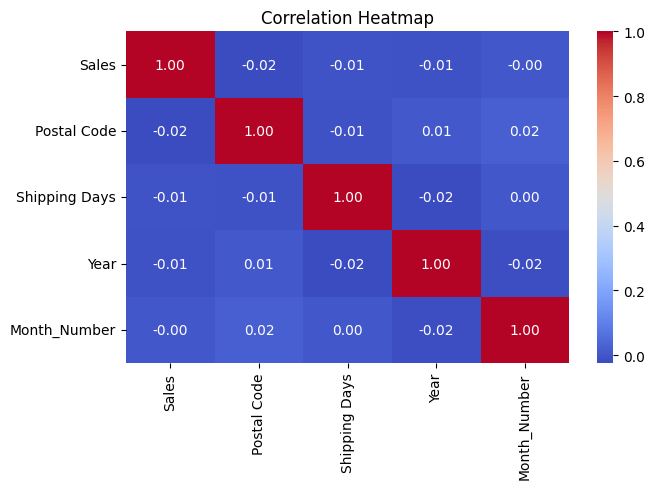

In [26]:
import seaborn as sns

corr_cols = ["Sales", "Postal Code", "Shipping Days", "Year", "Month_Number"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [27]:
#Statistical Summary

In [28]:
print("Mean:", df['Sales'].mean())
print("Median:", df['Sales'].median())
print("Standard Deviation:", df['Sales'].std())

Mean: 230.76905945918367
Median: 54.489999999999995
Standard Deviation: 626.6518748388042


In [29]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

### Insights:
    1. Most sales are small: The average sale is about 230.77, but the middle sale is only 54.49. This means most sales are on the lower side.
    2. 75% of sales are below 210.61: This shows that most customers make purchases of less than 210.
    3. A few sales are very large: Sales range from 0.44 to 22,638.48. A few very high sales increase the average and make the data spread out.

### Monthly Sales Forecasting Model

### A Linear Regression model is used to predict sales. Since the data is based on time, the first 80% of the months are used to train the model, and the last 20% are used to test it. The model also uses the month to understand seasonal sales patterns.

In [30]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

monthly = df.groupby("Month", as_index=False)["Sales"].sum()
monthly["time_index"] = np.arange(len(monthly))
monthly["month_num"] = monthly["Month"].dt.month
month_dummies = pd.get_dummies(monthly["month_num"], prefix="month", dtype=int)

In [31]:
X = pd.concat([monthly[["time_index"]], month_dummies], axis=1)
y = monthly["Sales"]

In [32]:
split_index = int(len(monthly) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 473.06,-19647.97,-28851.15,..., -3957.32, 32294.75, 33897.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['time_index','month_1','month_2',...,'month_10','month_11','month_12']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.471e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


In [34]:
prediction = model.predict(X_test)

In [35]:
print("Training months:", len(X_train))
print("Testing months:", len(X_test))

Training months: 38
Testing months: 10


In [36]:
r2 = r2_score(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
mae = mean_absolute_error(y_test, prediction)

print(f"R-Squared (R²): {r2:.3f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")

R-Squared (R²): 0.637
RMSE: 14,478.82
MAE: 10,520.28


### Actual vs predicted monthly sales

In [37]:
comparison_df = pd.DataFrame({
    "Month": monthly["Month"].iloc[split_index:].astype(str).values,
    "Actual Sales": y_test.values,
    "Predicted Sales": prediction
})

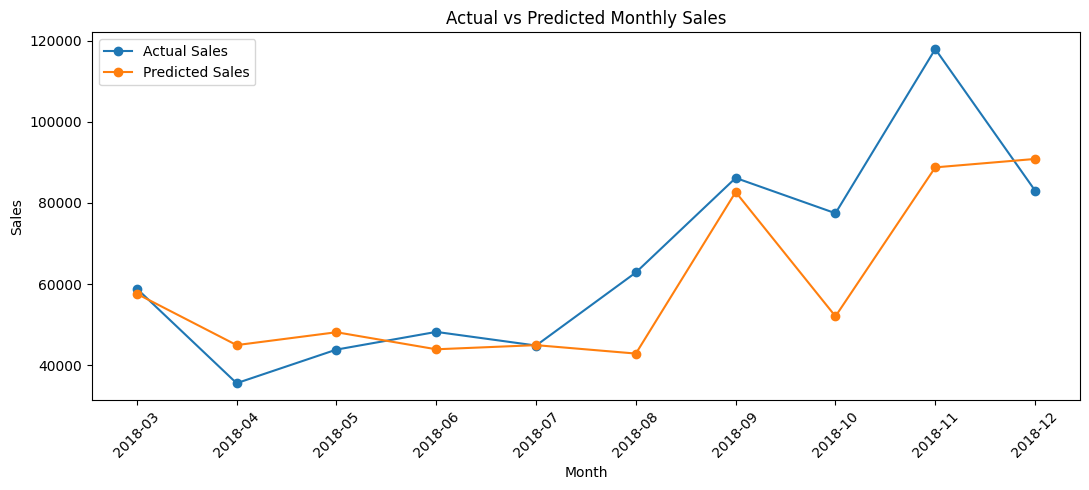

In [38]:
plt.figure(figsize=(11, 5))
plt.plot(comparison_df["Month"], comparison_df["Actual Sales"], marker="o", label="Actual Sales")
plt.plot(comparison_df["Month"], comparison_df["Predicted Sales"], marker="o", label="Predicted Sales")
plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
### Model interpretation

### The model has an R² score of about 0.637. This means the model can explain a good part of the changes in monthly sales, but it cannot predict every change accurately. The RMSE and MAE also show that there are still some prediction errors. So, this model can be used as a basicstarting point for forecasting, but it may need improvement for better results.

Sales forecast for the next 6 months:
     Month  Forecast Sales
0  2019-01    37764.566750
1  2019-02    29034.438200
2  2019-03    63266.716020
3  2019-04    50610.354720
4  2019-05    53783.571720
5  2019-06    49578.923087


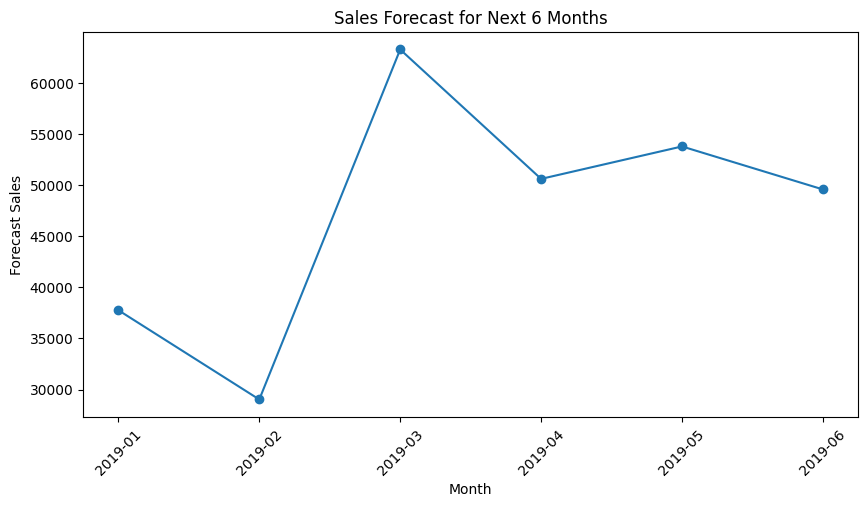

In [40]:
future = pd.DataFrame()
future["Month"] = pd.period_range(start=monthly["Month"].max() + 1,periods=6, freq="M")
future["time_index"] = range(len(monthly), len(monthly) + 6)
future["month_num"] = future["Month"].dt.month
month_data = pd.get_dummies(future["month_num"],prefix="month",dtype=int)

future_X = pd.concat(
    [future[["time_index"]], month_data],
    axis=1
)
future_X = future_X.reindex(columns=X.columns,fill_value=0)
future["Forecast Sales"] = model.predict(future_X)
print("Sales forecast for the next 6 months:")
print(future[["Month", "Forecast Sales"]])

# graph
plt.figure(figsize=(10, 5))
plt.plot(future["Month"].astype(str),future["Forecast Sales"],marker="o")
plt.title("Sales Forecast for Next 6 Months")
plt.xlabel("Month")
plt.ylabel("Forecast Sales")
plt.xticks(rotation=45)
plt.show()

## Business Recommendations
### 1. Focus on Technology products: Technology has the highest sales, so the business should keep enough stock and promote these products.
### 2. Focus on the West region: The West has the highest sales. The business should continue its marketing and sales efforts in this region.
### 3. Prepare for busy months: Sales are usually higher toward the end of the year, especially in November and December. The business should prepare  stock and marketing early.
### 4. Improve the South region: The South has the lowest sales. The business can offer special deals and study customer needs to increase sales.
### 5. Use the forecast as a starting point: The current model gives a basic sales forecast. A better model and more data could help make the          predictions more accurate.